# Transformers From Scratch
## NumPy → PyTorch: Understanding Every Step

A complete Transformer from raw math to PyTorch.
Every component built twice — NumPy first (math), PyTorch second (how to use it).

Based on: Vaswani et al. "Attention Is All You Need" (2017)

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
torch.manual_seed(42)

print("Numpy version:", np.__version__)
print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Numpy version: 2.4.6
PyTorch version: 2.12.0+cpu
Device: cpu


In [4]:
D_MODEL    = 64   # embedding size — BERT-base uses 768, GPT-3 uses 12288
N_HEADS    = 4    # attention heads — D_MODEL must be divisible by this
D_K        = D_MODEL // N_HEADS   # dimension per head = 16
D_FF       = 128  # feed-forward inner dim — typically 4 × D_MODEL
N_LAYERS   = 2    # encoder/decoder layers
MAX_SEQ    = 20   # max sequence length
VOCAB_SIZE = 100  # toy vocab

print(f"D_MODEL  = {D_MODEL}")
print(f"N_HEADS  = {N_HEADS}")
print(f"D_K      = {D_K}  ← D_MODEL / N_HEADS")
print(f"D_FF     = {D_FF}  ← 2 × D_MODEL")
print(f"N_LAYERS = {N_LAYERS}")

D_MODEL  = 64
N_HEADS  = 4
D_K      = 16  ← D_MODEL / N_HEADS
D_FF     = 128  ← 2 × D_MODEL
N_LAYERS = 2


## Step 1: Token Embeddings

Convert integer token IDs → dense vectors.

- Maintain a matrix of shape (vocab_size × d_model)
- Each token ID is just a row index into this matrix — a dictionary lookup
- The matrix is learned during training

Math:
  E = EmbeddingMatrix[token_ids]    shape: (seq_len × d_model)

In [5]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyEmbedding:
    def __init__(self, vocab_size, d_model):
        # Random init — in real training these weights get updated via backprop
        # Shape: (vocab_size × d_model) — one vector per token in vocabulary
        self.weights = np.random.randn(vocab_size, d_model) * 0.01

    def forward(self, token_ids):
        # token_ids: list of integers e.g. [3, 7, 42, 1]
        # This is literally just a row lookup — no computation
        # Output shape: (seq_len × d_model)
        return self.weights[token_ids]

# ── TEST ───────────────────────────────────────────────────────────────────

# Simulate a sentence: "The animal didn't cross" → token IDs
token_ids = [4, 12, 7, 33, 5, 18, 22, 9]   # 8 tokens
seq_len   = len(token_ids)

np_emb    = NumpyEmbedding(VOCAB_SIZE, D_MODEL)
np_output = np_emb.forward(token_ids)

print("Input  token_ids :", token_ids)
print("Input  shape     :", np.array(token_ids).shape)
print("Output shape     :", np_output.shape)
print(f"  → ({seq_len} tokens × {D_MODEL} d_model)")
print("\nFirst token vector (first 8 dims):", np.round(np_output[0, :8], 4))

Input  token_ids : [4, 12, 7, 33, 5, 18, 22, 9]
Input  shape     : (8,)
Output shape     : (8, 64)
  → (8 tokens × 64 d_model)

First token vector (first 8 dims): [ 0.0127 -0.0071  0.0044  0.0077 -0.0093 -0.0006 -0.0324 -0.0102]


In [6]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

# nn.Embedding does exactly the same thing — but with autograd built in
pt_emb    = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=D_MODEL)
pt_input  = torch.tensor(token_ids)       # shape: (seq_len,)
pt_output = pt_emb(pt_input)              # shape: (seq_len, d_model)

print("PyTorch input shape  :", pt_input.shape)
print("PyTorch output shape :", pt_output.shape)
print(f"  → ({seq_len} tokens × {D_MODEL} d_model)")
print("\nSame operation, autograd now tracks gradients automatically")
print("requires_grad:", pt_output.requires_grad)

PyTorch input shape  : torch.Size([8])
PyTorch output shape : torch.Size([8, 64])
  → (8 tokens × 64 d_model)

Same operation, autograd now tracks gradients automatically
requires_grad: True


## Step 2: Positional Encoding

Transformers process all tokens in parallel — unlike RNNs they have no
built-in sense of order. "dog bites man" and "man bites dog" would produce
identical embeddings without positional information.

Solution: add a positional vector to each embedding.

Math (sinusoidal — Vaswani et al.):
  PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
  PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

- pos  = position index (0, 1, 2, … seq_len)
- i    = dimension index (0, 1, 2, … d_model/2)
- Even dimensions → sine, Odd dimensions → cosine
- Result is ADDED to the token embedding, not concatenated

In [7]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyPositionalEncoding:
    def __init__(self, d_model, max_seq):
        # Build the full PE matrix once — shape: (max_seq × d_model)
        # We'll just slice it to the actual seq_len at runtime
        PE = np.zeros((max_seq, d_model))

        # pos: column vector of positions [0, 1, 2, ..., max_seq-1]
        pos = np.arange(max_seq).reshape(-1, 1)          # shape: (max_seq, 1)

        # i: row vector of dimension indices [0, 2, 4, ..., d_model-2]
        # We only need even indices because we handle even/odd pairs together
        i   = np.arange(0, d_model, 2)                   # shape: (d_model/2,)

        # The divisor term: 10000^(2i/d_model)
        div = np.power(10000, i / d_model)                # shape: (d_model/2,)

        # Even dimensions → sine
        PE[:, 0::2] = np.sin(pos / div)

        # Odd dimensions → cosine
        PE[:, 1::2] = np.cos(pos / div)

        self.PE = PE

    def forward(self, x):
        # x shape: (seq_len × d_model) — the token embeddings
        seq_len = x.shape[0]
        # Add positional encoding to embedding — same shape, element-wise add
        return x + self.PE[:seq_len, :]


# ── TEST ───────────────────────────────────────────────────────────────────

np_pe     = NumpyPositionalEncoding(D_MODEL, MAX_SEQ)
np_pe_out = np_pe.forward(np_output)   # np_output is from Cell 2

print("Token embedding shape     :", np_output.shape)
print("Positional encoding shape :", np_pe.PE[:seq_len].shape)
print("Output shape (emb + PE)   :", np_pe_out.shape)
print("  → shape unchanged — PE is ADDED, not concatenated")
print("\nPE matrix (first 4 positions, first 8 dims):")
print(np.round(np_pe.PE[:4, :8], 4))

Token embedding shape     : (8, 64)
Positional encoding shape : (8, 64)
Output shape (emb + PE)   : (8, 64)
  → shape unchanged — PE is ADDED, not concatenated

PE matrix (first 4 positions, first 8 dims):
[[ 0.      1.      0.      1.      0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.6816  0.7318  0.5332  0.846   0.4093  0.9124]
 [ 0.9093 -0.4161  0.9975  0.0709  0.9021  0.4315  0.7469  0.6649]
 [ 0.1411 -0.99    0.7783 -0.6279  0.9933 -0.116   0.9536  0.301 ]]


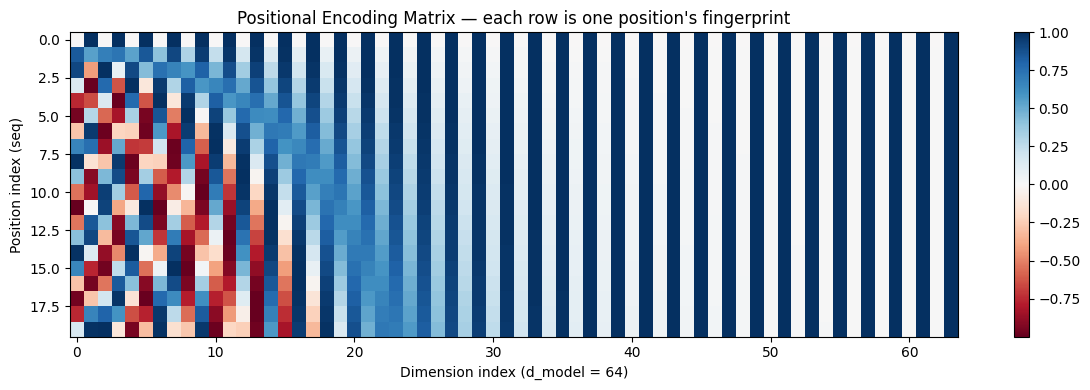

Each row = unique position fingerprint
Each column = one dimension oscillating at a different frequency
Low dims  → low frequency (changes slowly across positions)
High dims → high frequency (changes rapidly across positions)


In [8]:
# ── VISUALIZE THE PE MATRIX ────────────────────────────────────────────────

plt.figure(figsize=(12, 4))
plt.imshow(np_pe.PE[:MAX_SEQ, :], aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel("Dimension index (d_model = 64)")
plt.ylabel("Position index (seq)")
plt.title("Positional Encoding Matrix — each row is one position's fingerprint")
plt.tight_layout()
plt.show()

print("Each row = unique position fingerprint")
print("Each column = one dimension oscillating at a different frequency")
print("Low dims  → low frequency (changes slowly across positions)")
print("High dims → high frequency (changes rapidly across positions)")

In [9]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        PE = torch.zeros(max_seq, d_model)
        pos = torch.arange(0, max_seq).unsqueeze(1)          # (max_seq, 1)
        div = torch.pow(10000, torch.arange(0, d_model, 2) / d_model)

        PE[:, 0::2] = torch.sin(pos / div)
        PE[:, 1::2] = torch.cos(pos / div)

        # register_buffer → saved with model but not a trainable parameter
        self.register_buffer('PE', PE)

    def forward(self, x):
        # x shape: (seq_len, d_model)
        x = x + self.PE[:x.size(0), :]
        return self.dropout(x)

pt_pe     = PositionalEncoding(D_MODEL, MAX_SEQ)
pt_pe_out = pt_pe(pt_output)

print("PyTorch PE output shape:", pt_pe_out.shape)
print("requires_grad          :", pt_pe_out.requires_grad)
print("\nKey: register_buffer saves PE with the model but doesn't train it")
print("PE is fixed math — not learned — so no gradients needed")

PyTorch PE output shape: torch.Size([8, 64])
requires_grad          : True

Key: register_buffer saves PE with the model but doesn't train it
PE is fixed math — not learned — so no gradients needed


## Step 3: Layer Normalization

After attention and FFN, activations can have wildly different scales.
LayerNorm fixes this by normalizing each token's vector independently.

Math:
  μ  = mean(x)                        ← mean across d_model dimensions
  σ² = variance(x)                    ← variance across d_model dimensions
  x̂  = (x - μ) / √(σ² + ε)           ← normalize (ε prevents div by zero)
  y  = γ * x̂ + β                      ← scale and shift (learned)

Key points:
- Operates across the d_model dimension, NOT across the batch/sequence
- γ (gamma) and β (beta) are learned — model can undo normalization if needed
- ε (epsilon) = 1e-6, just prevents division by zero
- Applied as: LayerNorm(x + sublayer(x))  ← the "Add & Norm" you see in diagrams

In [10]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyLayerNorm:
    def __init__(self, d_model, eps=1e-6):
        self.eps   = eps
        # gamma and beta are learned parameters — initialized to 1 and 0
        # so at the start LayerNorm is an identity function
        self.gamma = np.ones(d_model)    # scale — shape: (d_model,)
        self.beta  = np.zeros(d_model)   # shift — shape: (d_model,)

    def forward(self, x):
        # x shape: (seq_len × d_model)
        # Compute mean and variance across the LAST axis (d_model dimension)
        # Each token gets normalized independently — keepdims for broadcasting
        mu      = x.mean(axis=-1, keepdims=True)       # shape: (seq_len, 1)
        var     = x.var(axis=-1, keepdims=True)         # shape: (seq_len, 1)

        # Normalize — zero mean, unit variance
        x_norm  = (x - mu) / np.sqrt(var + self.eps)   # shape: (seq_len, d_model)

        # Scale and shift with learned parameters
        return self.gamma * x_norm + self.beta          # shape: (seq_len, d_model)


# ── TEST ───────────────────────────────────────────────────────────────────

np_ln  = NumpyLayerNorm(D_MODEL)
# Use np_pe_out from Cell 3 as input — this is what comes out of PE step
np_ln_out = np_ln.forward(np_pe_out)

print("Input  shape:", np_pe_out.shape)
print("Output shape:", np_ln_out.shape)
print()

# Before normalization — each token has different mean/std
print("BEFORE LayerNorm:")
print(f"  Token 0 — mean: {np_pe_out[0].mean():.4f}  std: {np_pe_out[0].std():.4f}")
print(f"  Token 1 — mean: {np_pe_out[1].mean():.4f}  std: {np_pe_out[1].std():.4f}")
print(f"  Token 2 — mean: {np_pe_out[2].mean():.4f}  std: {np_pe_out[2].std():.4f}")

print()

# After normalization — every token has mean≈0, std≈1
print("AFTER LayerNorm:")
print(f"  Token 0 — mean: {np_ln_out[0].mean():.4f}  std: {np_ln_out[0].std():.4f}")
print(f"  Token 1 — mean: {np_ln_out[1].mean():.4f}  std: {np_ln_out[1].std():.4f}")
print(f"  Token 2 — mean: {np_ln_out[2].mean():.4f}  std: {np_ln_out[2].std():.4f}")

print()
print("Every token now has mean ≈ 0.0 and std ≈ 1.0")
print("This keeps activations stable no matter how deep the network goes")

Input  shape: (8, 64)
Output shape: (8, 64)

BEFORE LayerNorm:
  Token 0 — mean: 0.5006  std: 0.4974
  Token 1 — mean: 0.5423  std: 0.4535
  Token 2 — mean: 0.5353  std: 0.4603

AFTER LayerNorm:
  Token 0 — mean: -0.0000  std: 1.0000
  Token 1 — mean: -0.0000  std: 1.0000
  Token 2 — mean: 0.0000  std: 1.0000

Every token now has mean ≈ 0.0 and std ≈ 1.0
This keeps activations stable no matter how deep the network goes


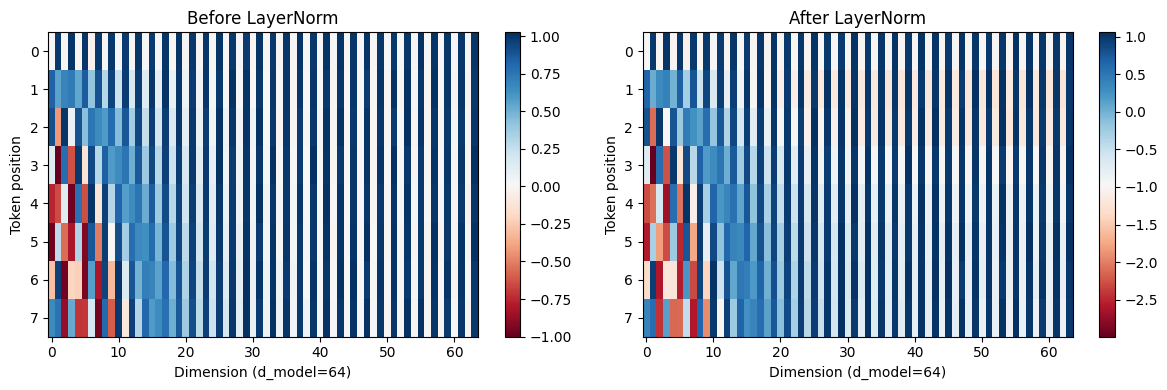

Notice: after LayerNorm the color scale is symmetric and consistent
Each row (token) now has the same overall brightness/contrast


In [11]:
# ── VISUALIZE BEFORE vs AFTER ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before — raw PE output values per token
axes[0].imshow(np_pe_out, aspect='auto', cmap='RdBu')
axes[0].set_title("Before LayerNorm")
axes[0].set_xlabel("Dimension (d_model=64)")
axes[0].set_ylabel("Token position")
plt.colorbar(axes[0].images[0], ax=axes[0])

# After — normalized
axes[1].imshow(np_ln_out, aspect='auto', cmap='RdBu')
axes[1].set_title("After LayerNorm")
axes[1].set_xlabel("Dimension (d_model=64)")
axes[1].set_ylabel("Token position")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

print("Notice: after LayerNorm the color scale is symmetric and consistent")
print("Each row (token) now has the same overall brightness/contrast")

In [12]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

# nn.LayerNorm does exactly this — normalized_shape is d_model
pt_ln     = nn.LayerNorm(normalized_shape=D_MODEL, eps=1e-6)
pt_ln_out = pt_ln(pt_pe_out)

print("PyTorch LayerNorm output shape:", pt_ln_out.shape)
print()

# Confirm same behavior
print("AFTER PyTorch LayerNorm:")
print(f"  Token 0 — mean: {pt_ln_out[0].mean().item():.4f}  std: {pt_ln_out[0].std().item():.4f}")
print(f"  Token 1 — mean: {pt_ln_out[1].mean().item():.4f}  std: {pt_ln_out[1].std().item():.4f}")
print()
print("gamma (ones)  shape:", pt_ln.weight.shape)
print("beta  (zeros) shape:", pt_ln.bias.shape)
print("Both are trainable — model can scale/shift after normalization")

PyTorch LayerNorm output shape: torch.Size([8, 64])

AFTER PyTorch LayerNorm:
  Token 0 — mean: 0.0000  std: 1.0079
  Token 1 — mean: 0.0000  std: 1.0079

gamma (ones)  shape: torch.Size([64])
beta  (zeros) shape: torch.Size([64])
Both are trainable — model can scale/shift after normalization


## Step 4: Scaled Dot-Product Attention

This is the core of the entire Transformer.

Every token asks: "which other tokens should I pay attention to?"
It does this by comparing its Query vector against every other token's Key vector.

Math:
  Attention(Q, K, V) = softmax( Q·Kᵀ / √d_k ) · V

Step by step:
  1. scores  = Q · Kᵀ          shape: (seq_len × seq_len)  — every pair scored
  2. scaled  = scores / √d_k   — prevents softmax saturation in high dimensions
  3. weights = softmax(scaled)  — rows sum to 1.0 — these are attention weights
  4. output  = weights · V     — weighted blend of value vectors

Why √d_k scaling?
  Dot products grow with dimension. At d_k=64, unscaled scores have std≈8.
  After dividing by √64=8, std≈1. Without this, softmax gets too peaked
  → near-zero gradients → model stops learning.

Optional mask (for decoder):
  Before softmax, add -inf to positions you want to block.
  After softmax, -inf becomes exactly 0 — those positions are ignored.

In [13]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

def numpy_softmax(x, axis=-1):
    # Subtract max for numerical stability — prevents exp() overflow
    # This doesn't change the output (softmax is shift-invariant)
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def numpy_scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q shape: (seq_len × d_k)
    K shape: (seq_len × d_k)
    V shape: (seq_len × d_k)
    mask shape: (seq_len × seq_len) — optional, None for encoder
    """
    d_k = Q.shape[-1]

    # Step 1: score every (query, key) pair
    # Q·Kᵀ → (seq_len × d_k) @ (d_k × seq_len) = (seq_len × seq_len)
    scores = Q @ K.T                          # shape: (seq_len, seq_len)

    # Step 2: scale — keeps variance stable regardless of d_k
    scores = scores / np.sqrt(d_k)            # shape: (seq_len, seq_len)

    # Step 3: apply mask if provided (used in decoder)
    # -1e9 instead of -inf to avoid NaN in softmax
    if mask is not None:
        scores = scores + mask * -1e9

    # Step 4: softmax — each row sums to 1.0
    weights = numpy_softmax(scores, axis=-1)  # shape: (seq_len, seq_len)

    # Step 5: weighted sum of values
    output = weights @ V                      # shape: (seq_len, d_k)

    return output, weights                    # return weights for visualization


# ── BUILD Q, K, V FROM OUR EMBEDDING ──────────────────────────────────────

# Create random projection matrices (in real transformer these are learned)
np.random.seed(42)
Wq = np.random.randn(D_MODEL, D_K) * 0.1    # shape: (64, 16)
Wk = np.random.randn(D_MODEL, D_K) * 0.1    # shape: (64, 16)
Wv = np.random.randn(D_MODEL, D_K) * 0.1    # shape: (64, 16)

# Project embeddings into Q, K, V spaces
# np_ln_out shape: (8, 64) — from LayerNorm step
Q = np_ln_out @ Wq    # shape: (8, 16) — "what am I looking for?"
K = np_ln_out @ Wk    # shape: (8, 16) — "what do I offer?"
V = np_ln_out @ Wv    # shape: (8, 16) — "what do I contribute?"

print("Projection matrices:")
print(f"  Wq: {Wq.shape}  Wk: {Wk.shape}  Wv: {Wv.shape}")
print()
print("Q, K, V shapes:")
print(f"  Q: {Q.shape}  K: {K.shape}  V: {V.shape}")
print(f"  → (seq_len × d_k) = ({seq_len} × {D_K})")

Projection matrices:
  Wq: (64, 16)  Wk: (64, 16)  Wv: (64, 16)

Q, K, V shapes:
  Q: (8, 16)  K: (8, 16)  V: (8, 16)
  → (seq_len × d_k) = (8 × 16)


In [14]:
# ── RUN ATTENTION ──────────────────────────────────────────────────────────

attn_output, attn_weights = numpy_scaled_dot_product_attention(Q, K, V)

print("Attention output shape  :", attn_output.shape)
print("Attention weights shape :", attn_weights.shape)
print(f"  → weights are (seq_len × seq_len) = ({seq_len} × {seq_len})")
print()

# Each row of weights sums to 1.0 — verify
print("Row sums of attention weights (should all be 1.0):")
print(np.round(attn_weights.sum(axis=-1), 4))
print()

# Show the raw score matrix BEFORE and AFTER scaling
raw_scores   = Q @ K.T
scaled_scores = raw_scores / np.sqrt(D_K)

print(f"Raw scores    — mean: {raw_scores.mean():.4f}  std: {raw_scores.std():.4f}")
print(f"Scaled scores — mean: {scaled_scores.mean():.4f}  std: {scaled_scores.std():.4f}")
print(f"\n√d_k = √{D_K} = {np.sqrt(D_K):.2f}  — this is what we divide by")
print("Scaling brings std closer to 1.0 → healthy softmax gradients")

Attention output shape  : (8, 16)
Attention weights shape : (8, 8)
  → weights are (seq_len × seq_len) = (8 × 8)

Row sums of attention weights (should all be 1.0):
[1. 1. 1. 1. 1. 1. 1. 1.]

Raw scores    — mean: -1.7478  std: 1.0948
Scaled scores — mean: -0.4369  std: 0.2737

√d_k = √16 = 4.00  — this is what we divide by
Scaling brings std closer to 1.0 → healthy softmax gradients


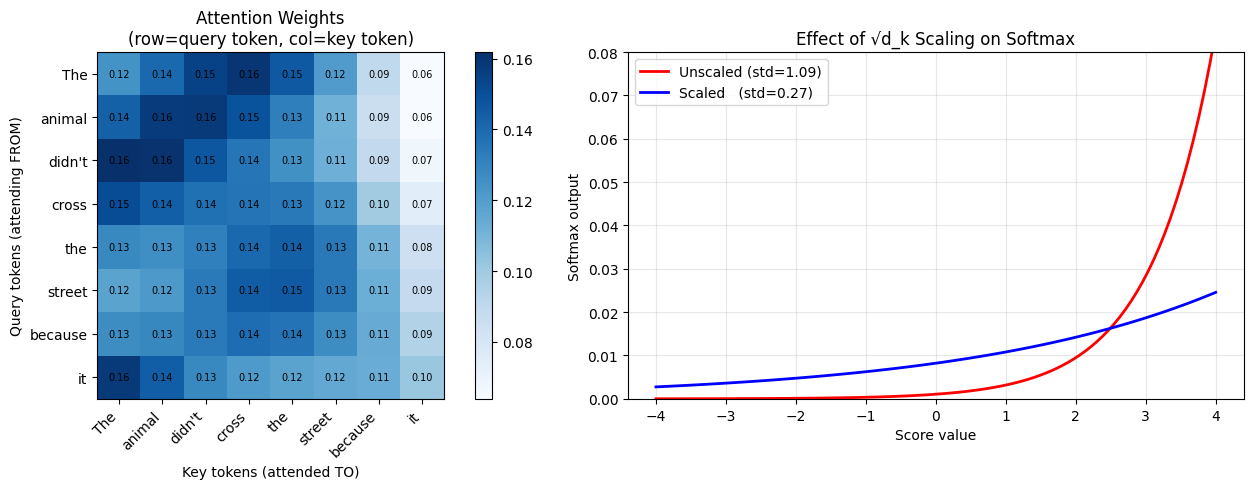

In [15]:
# ── VISUALIZE ATTENTION WEIGHTS ────────────────────────────────────────────

# Use our actual sentence tokens as labels
sentence = ["The", "animal", "didn't", "cross", "the", "street", "because", "it"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: attention weight heatmap
im = axes[0].imshow(attn_weights, cmap='Blues')
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels(sentence, rotation=45, ha='right')
axes[0].set_yticklabels(sentence)
axes[0].set_title("Attention Weights\n(row=query token, col=key token)")
axes[0].set_xlabel("Key tokens (attended TO)")
axes[0].set_ylabel("Query tokens (attending FROM)")
plt.colorbar(im, ax=axes[0])

# Annotate each cell with its weight value
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f"{attn_weights[i,j]:.2f}",
                    ha='center', va='center', fontsize=7,
                    color='white' if attn_weights[i,j] > 0.2 else 'black')

# Right: before vs after scaling effect on softmax
x = np.linspace(-4, 4, 100)
soft_raw    = np.exp(x * raw_scores.std())    / np.exp(x * raw_scores.std()).sum()
soft_scaled = np.exp(x * scaled_scores.std()) / np.exp(x * scaled_scores.std()).sum()

axes[1].plot(x, soft_raw,    label=f'Unscaled (std={raw_scores.std():.2f})',    color='red',  linewidth=2)
axes[1].plot(x, soft_scaled, label=f'Scaled   (std={scaled_scores.std():.2f})', color='blue', linewidth=2)
axes[1].set_title("Effect of √d_k Scaling on Softmax")
axes[1].set_xlabel("Score value")
axes[1].set_ylabel("Softmax output")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 0.08)

plt.tight_layout()
plt.show()

In [16]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

# Convert to PyTorch tensors
Q_pt = torch.tensor(Q, dtype=torch.float32)
K_pt = torch.tensor(K, dtype=torch.float32)
V_pt = torch.tensor(V, dtype=torch.float32)

# PyTorch has a built-in scaled dot product attention (PyTorch 2.0+)
pt_attn_out = F.scaled_dot_product_attention(Q_pt, K_pt, V_pt)
con
print("PyTorch scaled_dot_product_attention output:", pt_attn_out.shape)
print()

# Manual PyTorch version — same as our NumPy, so you see the equivalence
scores_pt  = (Q_pt @ K_pt.transpose(-2, -1)) / math.sqrt(D_K)
weights_pt = F.softmax(scores_pt, dim=-1)
output_pt  = weights_pt @ V_pt

print("Manual PyTorch attention output :", output_pt.shape)
print("Weights row sums (should be 1.0):", weights_pt.sum(dim=-1).detach().numpy().round(3))
print()
print("NumPy  output [0, :4]:", np.round(attn_output[0, :4], 4))
print("PyTorch output [0,:4]:", output_pt[0, :4].detach().numpy().round(4))
print("\nSame numbers — PyTorch is just NumPy math with autograd on top")

NameError: name 'con' is not defined

## Step 5: Multi-Head Attention

Single attention = one perspective on the sequence.
Multi-head attention = h parallel attention heads, each looking at different relationships.

Why multiple heads?
  One head might track syntax ("animal" is subject of "cross")
  Another tracks coreference ("it" refers to "animal")
  Another tracks semantic similarity
  Each head specializes by learning different Wq, Wk, Wv projections

Math:
  head_i  = Attention(Q·Wq_i, K·Wk_i, V·Wv_i)    ← h independent attentions
  concat  = Concat(head_1, head_2, ..., head_h)    ← shape: (seq_len × d_model)
  output  = concat · Wo                             ← final linear projection

Dimensions:
  Each head works in d_k = d_model / h space
  BERT-base: d_model=768, h=12, d_k=64
  Our model:  d_model=64,  h=4,  d_k=16
  Concatenating h heads of size d_k gives back d_model → no dimension loss

In [ ]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyMultiHeadAttention:
    def __init__(self, d_model, n_heads):
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads   # dimension per head

        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        # Each head has its own Wq, Wk, Wv — shape: (d_model × d_k) each
        # In practice these are stacked into one big matrix for efficiency
        # but we keep them separate here for clarity
        self.Wq = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(n_heads)]
        self.Wk = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(n_heads)]
        self.Wv = [np.random.randn(d_model, self.d_k) * 0.1 for _ in range(n_heads)]

        # Output projection — maps concatenated heads back to d_model
        # shape: (d_model × d_model)
        self.Wo = np.random.randn(d_model, d_model) * 0.1

    def attention(self, Q, K, V, mask=None):
        # Same scaled dot-product attention from Cell 5
        d_k    = Q.shape[-1]
        scores = Q @ K.T / np.sqrt(d_k)       # (seq_len, seq_len)
        if mask is not None:
            scores += mask * -1e9
        weights = numpy_softmax(scores)        # (seq_len, seq_len)
        return weights @ V, weights            # (seq_len, d_k), (seq_len, seq_len)

    def forward(self, x, mask=None):
        """
        x shape: (seq_len × d_model)
        For self-attention: Q, K, V all come from x
        For cross-attention: Q from decoder, K/V from encoder (Cell 10)
        """
        head_outputs = []
        all_weights  = []

        for i in range(self.n_heads):
            # Project x into Q, K, V for this head
            Q_i = x @ self.Wq[i]     # (seq_len, d_k)
            K_i = x @ self.Wk[i]     # (seq_len, d_k)
            V_i = x @ self.Wv[i]     # (seq_len, d_k)

            # Run attention for this head
            out_i, w_i = self.attention(Q_i, K_i, V_i, mask)
            head_outputs.append(out_i)    # (seq_len, d_k)
            all_weights.append(w_i)       # (seq_len, seq_len)

        # Concatenate all head outputs along last axis
        # h tensors of (seq_len, d_k) → (seq_len, h*d_k) = (seq_len, d_model)
        concat = np.concatenate(head_outputs, axis=-1)   # (seq_len, d_model)

        # Final linear projection
        output = concat @ self.Wo                         # (seq_len, d_model)

        return output, all_weights


# ── TEST ───────────────────────────────────────────────────────────────────

np.random.seed(42)
np_mha    = NumpyMultiHeadAttention(D_MODEL, N_HEADS)
mha_out, all_weights = np_mha.forward(np_ln_out)

print(f"Input  shape : {np_ln_out.shape}")
print(f"Output shape : {mha_out.shape}")
print(f"  → shape preserved — (seq_len × d_model) in, (seq_len × d_model) out")
print()
print(f"Number of heads     : {N_HEADS}")
print(f"Each head output    : (seq_len × d_k) = ({seq_len} × {D_K})")
print(f"After concat        : (seq_len × d_model) = ({seq_len} × {D_MODEL})")
print(f"After Wo projection : (seq_len × d_model) = ({seq_len} × {D_MODEL})")
print()
print(f"Attention weights per head — each shape: {all_weights[0].shape}")
print(f"  → {N_HEADS} heads × ({seq_len}×{seq_len}) weight matrices")

Input  shape : (8, 64)
Output shape : (8, 64)
  → shape preserved — (seq_len × d_model) in, (seq_len × d_model) out

Number of heads     : 4
Each head output    : (seq_len × d_k) = (8 × 16)
After concat        : (seq_len × d_model) = (8 × 64)
After Wo projection : (seq_len × d_model) = (8 × 64)

Attention weights per head — each shape: (8, 8)
  → 4 heads × (8×8) weight matrices


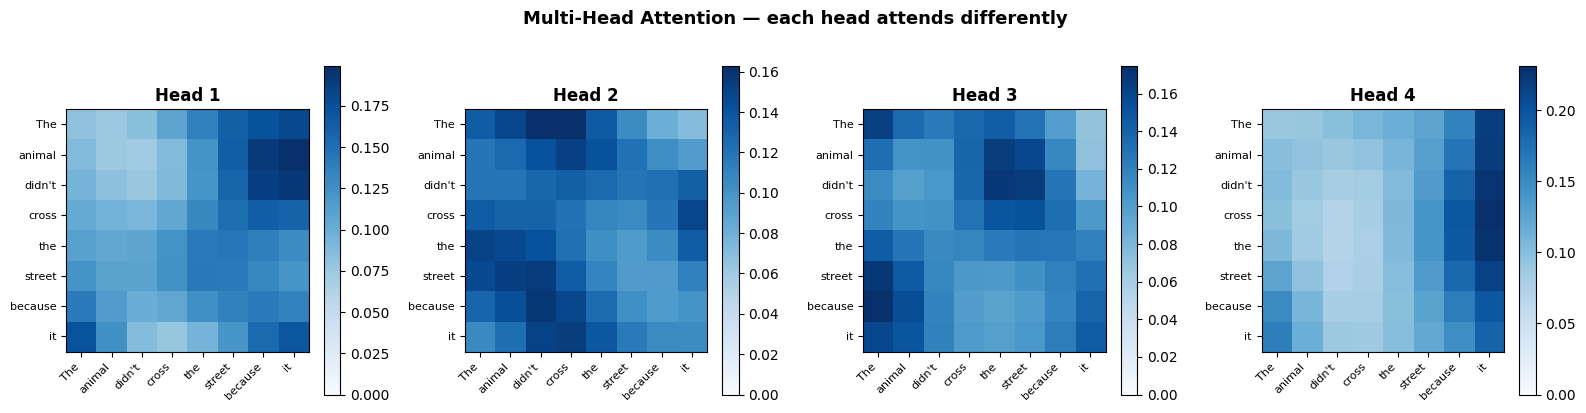

Each head has learned different Wq, Wk, Wv weights
→ each produces a different attention pattern
→ one might focus on adjacent tokens, another on semantically related ones
→ concatenating all heads gives the model multiple 'perspectives' at once


In [ ]:
# ── VISUALIZE ALL HEADS ────────────────────────────────────────────────────
# Each head learns different attention patterns — this is the key insight

sentence = ["The", "animal", "didn't", "cross", "the", "street", "because", "it"]

fig, axes = plt.subplots(1, N_HEADS, figsize=(16, 4))

for i, (ax, w) in enumerate(zip(axes, all_weights)):
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=w.max())
    ax.set_title(f"Head {i+1}", fontsize=12, fontweight='bold')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(sentence, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(sentence, fontsize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle("Multi-Head Attention — each head attends differently",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Each head has learned different Wq, Wk, Wv weights")
print("→ each produces a different attention pattern")
print("→ one might focus on adjacent tokens, another on semantically related ones")
print("→ concatenating all heads gives the model multiple 'perspectives' at once")

In [ ]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        # In PyTorch we use ONE big matrix instead of h separate ones
        # More efficient — one matmul instead of h matmuls
        self.Wq = nn.Linear(d_model, d_model, bias=False)  # (d_model → d_model)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        # x shape: (seq_len, d_model)
        # Reshape to (n_heads, seq_len, d_k) so each head gets its slice
        seq_len = x.size(0)
        x = x.view(seq_len, self.n_heads, self.d_k)  # (seq_len, h, d_k)
        return x.transpose(0, 1)                      # (h, seq_len, d_k)

    def forward(self, x, mask=None):
        # Project to Q, K, V — shape: (seq_len, d_model) each
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # Split into heads — shape: (n_heads, seq_len, d_k) each
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Scaled dot-product attention across all heads at once
        # (h, seq_len, d_k) @ (h, d_k, seq_len) → (h, seq_len, seq_len)
        scores  = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)   # (h, seq_len, seq_len)
        out     = weights @ V                  # (h, seq_len, d_k)

        # Merge heads back — (h, seq_len, d_k) → (seq_len, d_model)
        out = out.transpose(0, 1).contiguous()         # (seq_len, h, d_k)
        out = out.view(x.size(0), self.d_model)        # (seq_len, d_model)

        return self.Wo(out), weights.detach()


pt_mha         = MultiHeadAttention(D_MODEL, N_HEADS)
pt_mha_out, pt_weights = pt_mha(pt_ln_out)

print("PyTorch MHA output shape :", pt_mha_out.shape)
print("Attention weights shape  :", pt_weights.shape)
print(f"  → (n_heads × seq_len × seq_len) = ({N_HEADS} × {seq_len} × {seq_len})")
print()
print("Key difference from NumPy version:")
print("  NumPy  — h separate (d_model×d_k) matrices")
print("  PyTorch — one big (d_model×d_model) matrix, then reshape/split")
print("  Same math, PyTorch version is faster on GPU")

PyTorch MHA output shape : torch.Size([8, 64])
Attention weights shape  : torch.Size([4, 8, 8])
  → (n_heads × seq_len × seq_len) = (4 × 8 × 8)

Key difference from NumPy version:
  NumPy  — h separate (d_model×d_k) matrices
  PyTorch — one big (d_model×d_model) matrix, then reshape/split
  Same math, PyTorch version is faster on GPU


## Step 6: Feed-Forward Network (FFN)

After attention mixes information across tokens,
the FFN processes each token independently.

Why does it exist?
  Attention is purely linear — just weighted sums.
  The FFN adds non-linearity so the model can learn complex patterns.
  Think of it as: attention decides WHICH tokens to combine,
  FFN decides WHAT to do with the combined information.

Math:
  FFN(x) = max(0, x·W1 + b1) · W2 + b2

  W1 shape: (d_model × d_ff)   — expands  64 → 128
  W2 shape: (d_ff × d_model)   — compresses 128 → 64
  ReLU = max(0, x) — kills negative values, adds non-linearity

Key points:
  - Applied to EACH TOKEN INDEPENDENTLY — same weights, different inputs
  - d_ff is typically 4 × d_model (we use 2× here to keep it small)
  - Input and output shape are identical: (seq_len × d_model)
  - Modern models (Llama) use SwiGLU instead of ReLU — better performance

In [ ]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyFFN:
    def __init__(self, d_model, d_ff):
        # Two linear layers with ReLU in between
        # W1 expands: d_model → d_ff
        # W2 compresses: d_ff → d_model
        self.W1 = np.random.randn(d_model, d_ff) * 0.1   # (64, 128)
        self.b1 = np.zeros(d_ff)                           # (128,)
        self.W2 = np.random.randn(d_ff, d_model) * 0.1   # (128, 64)
        self.b2 = np.zeros(d_model)                        # (64,)

    def relu(self, x):
        # ReLU: max(0, x) — sets all negative values to zero
        return np.maximum(0, x)

    def forward(self, x):
        # x shape: (seq_len × d_model)

        # Step 1: expand — (seq_len, d_model) @ (d_model, d_ff) = (seq_len, d_ff)
        hidden = x @ self.W1 + self.b1         # (seq_len, d_ff)

        # Step 2: non-linearity — kills negatives, keeps positives
        hidden = self.relu(hidden)              # (seq_len, d_ff)

        # Step 3: compress — (seq_len, d_ff) @ (d_ff, d_model) = (seq_len, d_model)
        output = hidden @ self.W2 + self.b2    # (seq_len, d_model)

        return output, hidden   # return hidden to visualize the expansion


# ── TEST ───────────────────────────────────────────────────────────────────

np.random.seed(42)
np_ffn = NumpyFFN(D_MODEL, D_FF)
ffn_out, ffn_hidden = np_ffn.forward(mha_out)

print("FFN layer shapes:")
print(f"  W1 : {np_ffn.W1.shape}  — expand  {D_MODEL} → {D_FF}")
print(f"  W2 : {np_ffn.W2.shape}  — compress {D_FF} → {D_MODEL}")
print()
print(f"Input  shape  : {mha_out.shape}")
print(f"Hidden shape  : {ffn_hidden.shape}  ← after W1 + ReLU")
print(f"Output shape  : {ffn_out.shape}   ← after W2")
print()

# Show effect of ReLU — kills negatives
pre_relu  = mha_out @ np_ffn.W1 + np_ffn.b1
post_relu = np_ffn.relu(pre_relu)

neg_before = (pre_relu < 0).sum()
neg_after  = (post_relu < 0).sum()

print(f"Values before ReLU — negative count: {neg_before} / {pre_relu.size}")
print(f"Values after  ReLU — negative count: {neg_after}  / {post_relu.size}")
print(f"ReLU zeroed out {neg_before} values — {100*neg_before/pre_relu.size:.1f}% of activations")
print()
print("This sparsity is intentional — forces the model to use specific neurons")

FFN layer shapes:
  W1 : (64, 128)  — expand  64 → 128
  W2 : (128, 64)  — compress 128 → 64

Input  shape  : (8, 64)
Hidden shape  : (8, 128)  ← after W1 + ReLU
Output shape  : (8, 64)   ← after W2

Values before ReLU — negative count: 549 / 1024
Values after  ReLU — negative count: 0  / 1024
ReLU zeroed out 549 values — 53.6% of activations

This sparsity is intentional — forces the model to use specific neurons


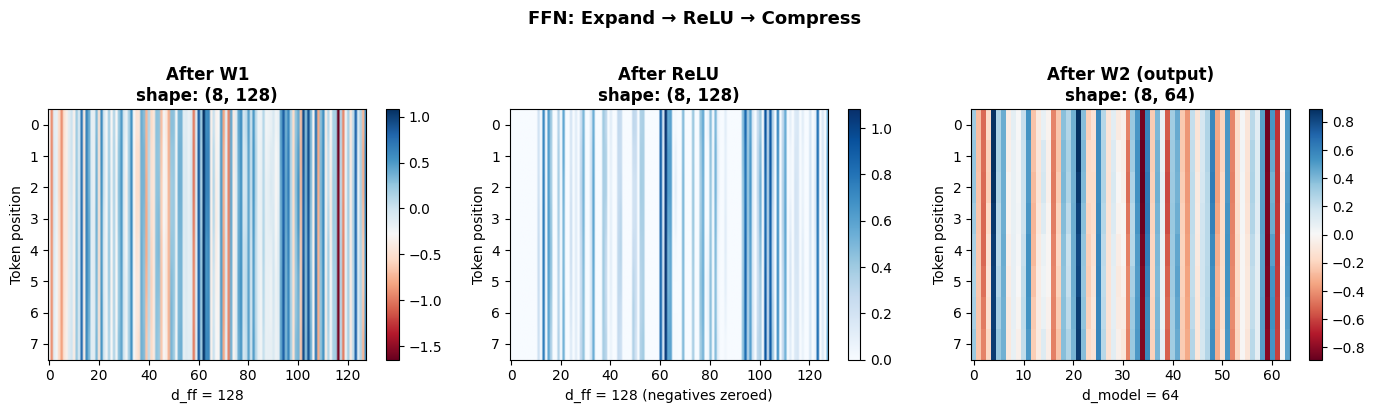

In [ ]:
# ── VISUALIZE EXPAND → RELU → COMPRESS ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Before ReLU — negative values present
im0 = axes[0].imshow(pre_relu, aspect='auto', cmap='RdBu')
axes[0].set_title(f"After W1\nshape: {pre_relu.shape}", fontweight='bold')
axes[0].set_xlabel(f"d_ff = {D_FF}")
axes[0].set_ylabel("Token position")
plt.colorbar(im0, ax=axes[0])

# After ReLU — all negatives zeroed
im1 = axes[1].imshow(post_relu, aspect='auto', cmap='Blues')
axes[1].set_title(f"After ReLU\nshape: {post_relu.shape}", fontweight='bold')
axes[1].set_xlabel(f"d_ff = {D_FF} (negatives zeroed)")
axes[1].set_ylabel("Token position")
plt.colorbar(im1, ax=axes[1])

# After W2 — back to d_model
im2 = axes[2].imshow(ffn_out, aspect='auto', cmap='RdBu')
axes[2].set_title(f"After W2 (output)\nshape: {ffn_out.shape}", fontweight='bold')
axes[2].set_xlabel(f"d_model = {D_MODEL}")
axes[2].set_ylabel("Token position")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("FFN: Expand → ReLU → Compress", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),    # expand
            nn.ReLU(),                    # non-linearity
            nn.Dropout(dropout),          # regularization
            nn.Linear(d_ff, d_model),    # compress
        )

    def forward(self, x):
        return self.net(x)


pt_ffn     = FeedForward(D_MODEL, D_FF)
pt_ffn_out = pt_ffn(pt_mha_out)

print("PyTorch FFN output shape:", pt_ffn_out.shape)
print()
print("Parameter count:")
for name, p in pt_ffn.named_parameters():
    print(f"  {name:20s} shape: {tuple(p.shape)}  params: {p.numel()}")
total = sum(p.numel() for p in pt_ffn.parameters())
print(f"\n  Total FFN params: {total}")
print(f"  In BERT-base: d_model=768, d_ff=3072 → FFN params ≈ {768*3072*2:,}")

PyTorch FFN output shape: torch.Size([8, 64])

Parameter count:
  net.0.weight         shape: (128, 64)  params: 8192
  net.0.bias           shape: (128,)  params: 128
  net.3.weight         shape: (64, 128)  params: 8192
  net.3.bias           shape: (64,)  params: 64

  Total FFN params: 16576
  In BERT-base: d_model=768, d_ff=3072 → FFN params ≈ 4,718,592


## Step 7: Residual Connection + Add & Norm

Every sublayer (attention, FFN) is wrapped with:
  output = LayerNorm(x + sublayer(x))

This is called "Add & Norm" in the original paper.

Why residual connections?
  In deep networks, gradients shrink as they flow backward through many layers.
  By the time they reach early layers — almost zero. Model stops learning.

  Residual connection adds a DIRECT PATH for gradients:
    output = x + sublayer(x)
    gradient flows through both paths — the sublayer AND the skip connection
    even if sublayer gradient → 0, gradient still flows through x directly

Why LayerNorm after?
  x + sublayer(x) can have arbitrary scale — normalizing keeps it stable.

Math:
  output = LayerNorm( x + sublayer(x) )
               ↑            ↑
           original     transformed
             input         input
              ↑
         skip connection — bypasses the sublayer entirely

In [ ]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyResidualBlock:
    def __init__(self, d_model, eps=1e-6):
        self.norm = NumpyLayerNorm(d_model, eps)

    def forward(self, x, sublayer_output):
        """
        x              : original input before sublayer — shape: (seq_len, d_model)
        sublayer_output: output of attention or FFN    — shape: (seq_len, d_model)

        The residual adds x back to the sublayer output BEFORE normalizing.
        This is Post-LN (original paper).
        Modern models use Pre-LN: sublayer(LayerNorm(x)) + x
        """
        return self.norm.forward(x + sublayer_output)


# ── TEST ───────────────────────────────────────────────────────────────────

np_residual = NumpyResidualBlock(D_MODEL)

# Simulating: x = input to MHA, sublayer_output = MHA output
x_input   = np_ln_out    # original input — shape (8, 64)
res_out   = np_residual.forward(x_input, mha_out)

print("Residual connection:")
print(f"  x (input)          shape: {x_input.shape}")
print(f"  sublayer output    shape: {mha_out.shape}")
print(f"  x + sublayer       shape: {(x_input + mha_out).shape}")
print(f"  LayerNorm(x + sub) shape: {res_out.shape}")
print()

# Show the three signals
print("Signal magnitudes (mean absolute value):")
print(f"  x alone          : {np.abs(x_input).mean():.4f}")
print(f"  sublayer alone   : {np.abs(mha_out).mean():.4f}")
print(f"  x + sublayer     : {np.abs(x_input + mha_out).mean():.4f}")
print(f"  after LayerNorm  : {np.abs(res_out).mean():.4f}")
print()
print("LayerNorm brings it back to a consistent scale after adding")

Residual connection:
  x (input)          shape: (8, 64)
  sublayer output    shape: (8, 64)
  x + sublayer       shape: (8, 64)
  LayerNorm(x + sub) shape: (8, 64)

Signal magnitudes (mean absolute value):
  x alone          : 0.9260
  sublayer alone   : 0.4948
  x + sublayer     : 0.9169
  after LayerNorm  : 0.8199

LayerNorm brings it back to a consistent scale after adding


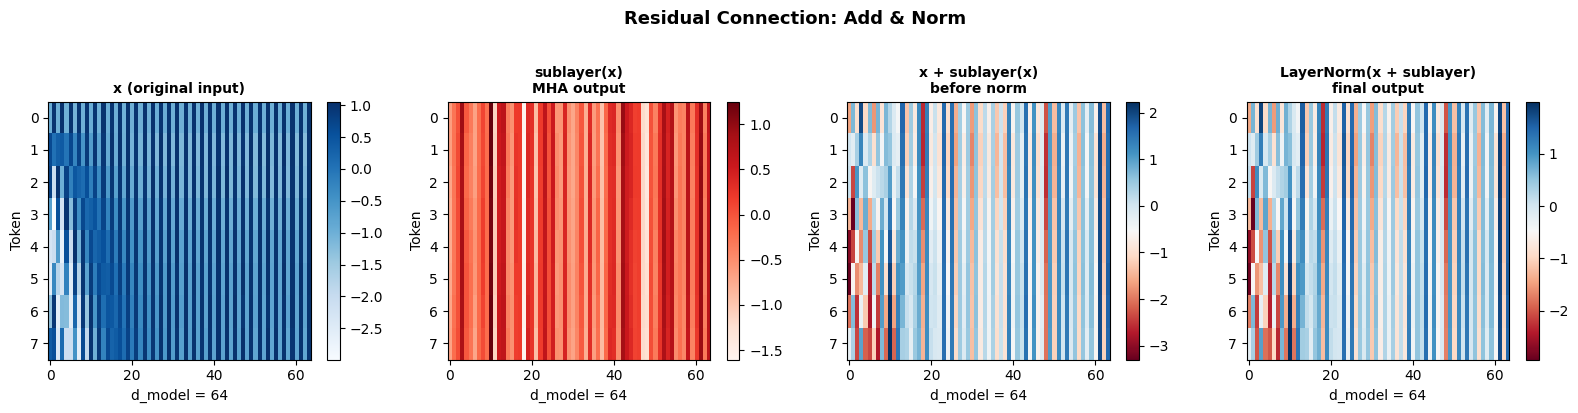

The skip connection (blue) and sublayer (red) are ADDED together
LayerNorm then standardizes the result back to mean=0, std=1
This is applied twice in each encoder layer: after MHA and after FFN


In [ ]:
# ── VISUALIZE SKIP CONNECTION EFFECT ──────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

data = [
    (x_input,             "x (original input)",    "Blues"),
    (mha_out,             "sublayer(x)\nMHA output", "Reds"),
    (x_input + mha_out,   "x + sublayer(x)\nbefore norm", "RdBu"),
    (res_out,             "LayerNorm(x + sublayer)\nfinal output", "RdBu"),
]

for ax, (d, title, cmap) in zip(axes, data):
    im = ax.imshow(d, aspect='auto', cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(f"d_model = {D_MODEL}")
    ax.set_ylabel("Token")
    plt.colorbar(im, ax=ax)

plt.suptitle("Residual Connection: Add & Norm", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("The skip connection (blue) and sublayer (red) are ADDED together")
print("LayerNorm then standardizes the result back to mean=0, std=1")
print("This is applied twice in each encoder layer: after MHA and after FFN")

In [ ]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

# In PyTorch this is just two lines — but now you know exactly what they do
pt_norm = nn.LayerNorm(D_MODEL)

# Post-LN style (original paper)
pt_res_out = pt_norm(pt_mha_out + pt_ln_out)

print("PyTorch residual output shape:", pt_res_out.shape)
print()
print("In code it's always written as:")
print("  x = LayerNorm(x + self.attention(x))   ← after attention")
print("  x = LayerNorm(x + self.ffn(x))         ← after FFN")
print()
print("Pre-LN (modern) version:")
print("  x = x + self.attention(LayerNorm(x))   ← norm BEFORE sublayer")
print("  x = x + self.ffn(LayerNorm(x))         ← more stable training")

PyTorch residual output shape: torch.Size([8, 64])

In code it's always written as:
  x = LayerNorm(x + self.attention(x))   ← after attention
  x = LayerNorm(x + self.ffn(x))         ← after FFN

Pre-LN (modern) version:
  x = x + self.attention(LayerNorm(x))   ← norm BEFORE sublayer
  x = x + self.ffn(LayerNorm(x))         ← more stable training


## Step 8: Encoder Block + Encoder Stack

Now we assemble everything built so far into one complete Encoder Layer.

One Encoder Layer =
  1. Multi-Head Self-Attention
  2. Add & Norm  (residual)
  3. Feed-Forward Network
  4. Add & Norm  (residual)

The full Encoder = N of these layers stacked.
Each layer refines the representations built by the previous one.

Data flow:
  x → [MHA → Add&Norm] → [FFN → Add&Norm] → x'
  x' → [MHA → Add&Norm] → [FFN → Add&Norm] → x''
  ... repeated N_LAYERS times

Input  shape: (seq_len × d_model)
Output shape: (seq_len × d_model)   ← same shape all the way through

BERT-base  : N=12 layers, d_model=768
GPT-3      : N=96 layers, d_model=12288
Our model  : N=2  layers, d_model=64

In [ ]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

class NumpyEncoderLayer:
    def __init__(self, d_model, n_heads, d_ff):
        # All components we built in previous cells
        self.mha      = NumpyMultiHeadAttention(d_model, n_heads)
        self.ffn      = NumpyFFN(d_model, d_ff)
        self.norm1    = NumpyLayerNorm(d_model)   # after MHA
        self.norm2    = NumpyLayerNorm(d_model)   # after FFN

    def forward(self, x, mask=None):
        # ── Sub-layer 1: Multi-Head Self-Attention + Add & Norm ──
        mha_out, weights = self.mha.forward(x, mask)
        x = self.norm1.forward(x + mha_out)       # Add & Norm

        # ── Sub-layer 2: Feed-Forward Network + Add & Norm ──
        ffn_out, _       = self.ffn.forward(x)
        x = self.norm2.forward(x + ffn_out)       # Add & Norm

        return x, weights


class NumpyEncoder:
    def __init__(self, d_model, n_heads, d_ff, n_layers):
        # Stack N identical encoder layers
        # Each layer has its OWN weights — not shared
        self.layers = [
            NumpyEncoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ]

    def forward(self, x, mask=None):
        # Pass through each layer sequentially
        # Output of layer N becomes input of layer N+1
        layer_outputs = []
        all_weights   = []

        for i, layer in enumerate(self.layers):
            x, weights = layer.forward(x, mask)
            layer_outputs.append(x.copy())
            all_weights.append(weights)
            print(f"  Layer {i+1} output shape: {x.shape}  "
                  f"mean: {x.mean():.4f}  std: {x.std():.4f}")

        return x, layer_outputs, all_weights


# ── TEST ───────────────────────────────────────────────────────────────────

np.random.seed(42)
np_encoder   = NumpyEncoder(D_MODEL, N_HEADS, D_FF, N_LAYERS)

# Start from positional encoded embeddings — shape: (8, 64)
print("Running full encoder stack...")
print(f"Input shape: {np_pe_out.shape}")
print()

enc_out, layer_outputs, enc_weights = np_encoder.forward(np_pe_out)

print()
print(f"Final encoder output shape: {enc_out.shape}")
print(f"  → ({seq_len} tokens × {D_MODEL} d_model)")
print()
print("Each token now has CONTEXTUAL meaning baked in.")
print("'it' no longer has the same vector as when it entered —")
print("it now contains information from 'animal', 'cross', 'tired'")

Running full encoder stack...
Input shape: (8, 64)

  Layer 1 output shape: (8, 64)  mean: -0.0000  std: 1.0000
  Layer 2 output shape: (8, 64)  mean: 0.0000  std: 1.0000

Final encoder output shape: (8, 64)
  → (8 tokens × 64 d_model)

Each token now has CONTEXTUAL meaning baked in.
'it' no longer has the same vector as when it entered —
it now contains information from 'animal', 'cross', 'tired'


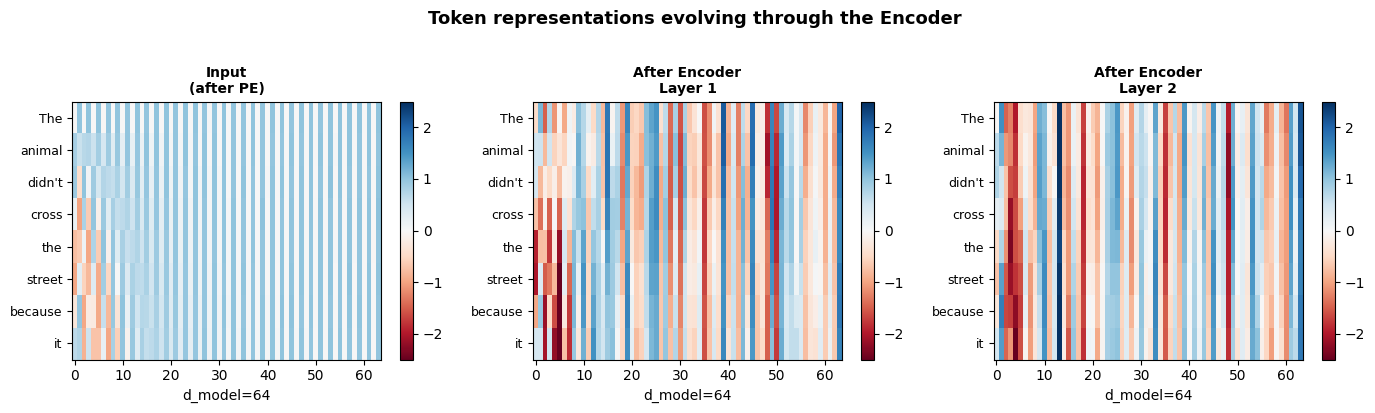

Each layer refines the representations.
By the final layer, each token vector encodes its meaning
IN THE CONTEXT of all surrounding tokens.


In [ ]:
# ── VISUALIZE HOW REPRESENTATIONS CHANGE ACROSS LAYERS ────────────────────

fig, axes = plt.subplots(1, N_LAYERS + 1, figsize=(14, 4))
sentence  = ["The", "animal", "didn't", "cross", "the", "street", "because", "it"]

all_reps = [np_pe_out] + layer_outputs
titles   = ["Input\n(after PE)"] + [f"After Encoder\nLayer {i+1}"
                                     for i in range(N_LAYERS)]

for ax, rep, title in zip(axes, all_reps, titles):
    im = ax.imshow(rep, aspect='auto', cmap='RdBu',
                   vmin=-2.5, vmax=2.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(sentence, fontsize=9)
    ax.set_xlabel(f"d_model={D_MODEL}")
    plt.colorbar(im, ax=ax)

plt.suptitle("Token representations evolving through the Encoder",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Each layer refines the representations.")
print("By the final layer, each token vector encodes its meaning")
print("IN THE CONTEXT of all surrounding tokens.")

In [ ]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha   = MultiHeadAttention(d_model, n_heads)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention + residual
        mha_out, _ = self.mha(x, mask)
        x = self.norm1(x + self.drop(mha_out))

        # FFN + residual
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)   # final norm after all layers


pt_encoder = Encoder(D_MODEL, N_HEADS, D_FF, N_LAYERS)
pt_enc_out = pt_encoder(pt_pe_out)

print("PyTorch Encoder output shape:", pt_enc_out.shape)
print()

# Count parameters
total_params = sum(p.numel() for p in pt_encoder.parameters())
print(f"Encoder parameter count : {total_params:,}")
print(f"  Our tiny model        : {total_params:,}")
print(f"  BERT-base encoder     : ~85,000,000")
print()
print("Encoder done. Output = contextual embeddings for every input token.")
print("These get passed to the DECODER as K and V in cross-attention.")

PyTorch Encoder output shape: torch.Size([8, 64])

Encoder parameter count : 66,560
  Our tiny model        : 66,560
  BERT-base encoder     : ~85,000,000

Encoder done. Output = contextual embeddings for every input token.
These get passed to the DECODER as K and V in cross-attention.


## Step 9: Decoder Block + Decoder Stack

The Decoder is the most complex component. Each decoder layer has THREE sublayers:

  1. Masked Multi-Head Self-Attention
       - Attends to previously generated tokens only
       - MASK prevents looking at future positions
       - Q, K, V all come from the decoder's own input

  2. Cross-Attention (Encoder → Decoder)
       - Q comes from decoder (what am I trying to generate?)
       - K, V come from ENCODER OUTPUT (what did the source say?)
       - This is the bridge between source and target language
       - No mask needed here

  3. Feed-Forward Network + Add & Norm
       - Identical to encoder FFN

Data flow:
  target_tokens
      ↓
  [Masked Self-Attn → Add&Norm]   ← only sees past tokens
      ↓
  [Cross-Attention  → Add&Norm]   ← reads encoder output
      ↓
  [FFN → Add&Norm]
      ↓
  decoder output

The causal mask:
  [[0, -inf, -inf, -inf],     token 0 sees only itself
   [0,  0,   -inf, -inf],     token 1 sees 0,1
   [0,  0,    0,   -inf],     token 2 sees 0,1,2
   [0,  0,    0,    0  ]]     token 3 sees all

In [ ]:
# ── NUMPY ──────────────────────────────────────────────────────────────────

def make_causal_mask(seq_len):
    """
    Creates a causal (autoregressive) mask.
    Upper triangle = 1 (will be multiplied by -1e9 → effectively -inf)
    Lower triangle + diagonal = 0 (allowed to attend)

    Shape: (seq_len × seq_len)
    """
    # np.triu extracts upper triangle
    # k=1 means start one above the diagonal (diagonal stays 0)
    mask = np.triu(np.ones((seq_len, seq_len)), k=1)
    return mask   # 1 = blocked, 0 = allowed


# Visualize the mask
tgt_len   = 6
causal_mask = make_causal_mask(tgt_len)

print("Causal mask for seq_len=6:")
print(causal_mask.astype(int))
print()
print("1 = blocked (-inf before softmax → 0 after softmax)")
print("0 = allowed")
print()
print("Token at position i can only attend to positions 0..i")

Causal mask for seq_len=6:
[[0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]

1 = blocked (-inf before softmax → 0 after softmax)
0 = allowed

Token at position i can only attend to positions 0..i


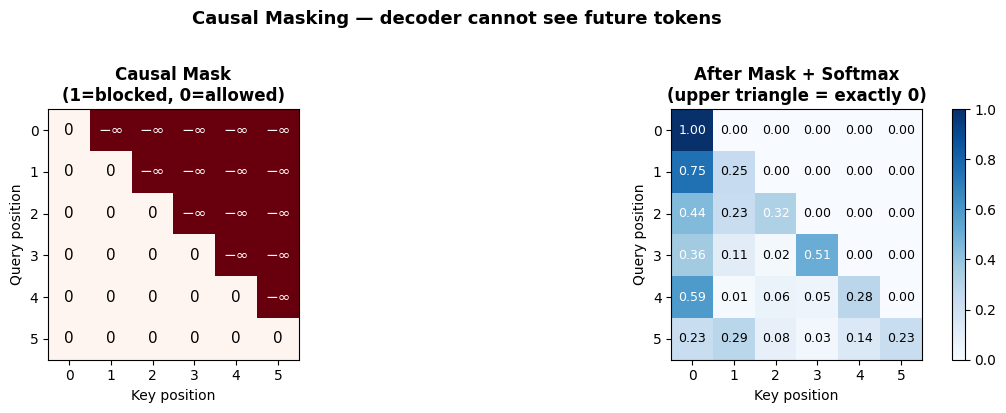

In [ ]:
# ── VISUALIZE CAUSAL MASK ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw mask
axes[0].imshow(causal_mask, cmap='Reds', vmin=0, vmax=1)
axes[0].set_title("Causal Mask\n(1=blocked, 0=allowed)", fontweight='bold')
for i in range(tgt_len):
    for j in range(tgt_len):
        axes[0].text(j, i, "−∞" if causal_mask[i,j] else "0",
                    ha='center', va='center', fontsize=11,
                    color='white' if causal_mask[i,j] else 'black')
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

# What attention looks like after applying mask + softmax
np.random.seed(0)
raw   = np.random.randn(tgt_len, tgt_len)
masked = raw + causal_mask * -1e9
after_softmax = numpy_softmax(masked)

im = axes[1].imshow(after_softmax, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title("After Mask + Softmax\n(upper triangle = exactly 0)", fontweight='bold')
for i in range(tgt_len):
    for j in range(tgt_len):
        axes[1].text(j, i, f"{after_softmax[i,j]:.2f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if after_softmax[i,j] > 0.3 else 'black')
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")
plt.colorbar(im, ax=axes[1])

plt.suptitle("Causal Masking — decoder cannot see future tokens",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── NUMPY DECODER LAYER ────────────────────────────────────────────────────

class NumpyDecoderLayer:
    def __init__(self, d_model, n_heads, d_ff):
        # Three sublayers — each with own weights
        self.masked_mha  = NumpyMultiHeadAttention(d_model, n_heads)  # sublayer 1
        self.cross_mha   = NumpyMultiHeadAttention(d_model, n_heads)  # sublayer 2
        self.ffn         = NumpyFFN(d_model, d_ff)                    # sublayer 3
        self.norm1       = NumpyLayerNorm(d_model)
        self.norm2       = NumpyLayerNorm(d_model)
        self.norm3       = NumpyLayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        x              : decoder input tokens  shape: (tgt_len × d_model)
        encoder_output : from encoder          shape: (src_len × d_model)
        src_mask       : padding mask for encoder (optional)
        tgt_mask       : causal mask for decoder — REQUIRED
        """

        # ── Sublayer 1: Masked Self-Attention ────────────────────────────
        # Q, K, V all come from x (decoder's own tokens)
        # tgt_mask prevents attending to future tokens
        masked_out, w1 = self.masked_mha.forward(x, tgt_mask)
        x = self.norm1.forward(x + masked_out)          # Add & Norm

        # ── Sublayer 2: Cross-Attention ───────────────────────────────────
        # Q comes from decoder (x), K and V come from encoder_output
        # We need to temporarily override the forward to use different Q,K,V
        cross_out, w2  = self._cross_attention(x, encoder_output, src_mask)
        x = self.norm2.forward(x + cross_out)           # Add & Norm

        # ── Sublayer 3: FFN ───────────────────────────────────────────────
        ffn_out, _     = self.ffn.forward(x)
        x = self.norm3.forward(x + ffn_out)             # Add & Norm

        return x, w1, w2

    def _cross_attention(self, decoder_x, encoder_out, mask=None):
        """
        Cross-attention: Q from decoder, K and V from encoder.
        decoder_x  shape: (tgt_len × d_model)
        encoder_out shape: (src_len × d_model)
        """
        # Use head 0's weights for simplicity — in real impl all heads run
        # We reuse cross_mha's projection matrices
        d_k = self.cross_mha.d_k

        all_head_outputs = []
        all_weights      = []

        for i in range(self.cross_mha.n_heads):
            # Q from decoder
            Q = decoder_x   @ self.cross_mha.Wq[i]   # (tgt_len, d_k)
            # K, V from encoder — THIS IS THE BRIDGE
            K = encoder_out @ self.cross_mha.Wk[i]   # (src_len, d_k)
            V = encoder_out @ self.cross_mha.Wv[i]   # (src_len, d_k)

            # Attention: (tgt_len, d_k) × (d_k, src_len) → (tgt_len, src_len)
            scores  = Q @ K.T / np.sqrt(d_k)
            weights = numpy_softmax(scores)           # (tgt_len, src_len)
            out     = weights @ V                     # (tgt_len, d_k)

            all_head_outputs.append(out)
            all_weights.append(weights)

        concat = np.concatenate(all_head_outputs, axis=-1)  # (tgt_len, d_model)
        output = concat @ self.cross_mha.Wo                  # (tgt_len, d_model)
        return output, all_weights


class NumpyDecoder:
    def __init__(self, d_model, n_heads, d_ff, n_layers):
        self.layers = [
            NumpyDecoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ]

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        for i, layer in enumerate(self.layers):
            x, w1, w2 = layer.forward(x, encoder_output, src_mask, tgt_mask)
            print(f"  Decoder layer {i+1} — "
                  f"self-attn: {w1[0].shape}  "
                  f"cross-attn: {w2[0].shape}")
        return x

In [ ]:
# ── TEST ───────────────────────────────────────────────────────────────────

np.random.seed(42)

# Simulate target sequence — e.g. partial Hindi translation (5 tokens so far)
tgt_token_ids = [2, 15, 8, 44, 31]
tgt_len       = len(tgt_token_ids)

# Embed target tokens + positional encoding
tgt_emb_layer = NumpyEmbedding(VOCAB_SIZE, D_MODEL)
tgt_pe_layer  = NumpyPositionalEncoding(D_MODEL, MAX_SEQ)
tgt_emb       = tgt_emb_layer.forward(tgt_token_ids)
tgt_input     = tgt_pe_layer.forward(tgt_emb)

# Build causal mask for target sequence
tgt_mask = make_causal_mask(tgt_len)   # shape: (5, 5)

print("Target sequence:")
print(f"  token ids     : {tgt_token_ids}")
print(f"  embedded shape: {tgt_input.shape}")
print(f"  causal mask   : {tgt_mask.shape}")
print(f"  encoder output: {enc_out.shape}")
print()

# Run decoder
np_decoder = NumpyDecoder(D_MODEL, N_HEADS, D_FF, N_LAYERS)
print("Running decoder stack...")
dec_out = np_decoder.forward(tgt_input, enc_out, tgt_mask=tgt_mask)

print()
print(f"Decoder output shape: {dec_out.shape}")
print(f"  → ({tgt_len} target tokens × {D_MODEL} d_model)")
print()
print("Cross-attention weight shape (tgt_len × src_len):")
print(f"  ({tgt_len} decoder tokens × {seq_len} encoder tokens)")
print("  → each decoder token can attend to ANY encoder token")

Target sequence:
  token ids     : [2, 15, 8, 44, 31]
  embedded shape: (5, 64)
  causal mask   : (5, 5)
  encoder output: (8, 64)

Running decoder stack...
  Decoder layer 1 — self-attn: (5, 5)  cross-attn: (5, 8)
  Decoder layer 2 — self-attn: (5, 5)  cross-attn: (5, 8)

Decoder output shape: (5, 64)
  → (5 target tokens × 64 d_model)

Cross-attention weight shape (tgt_len × src_len):
  (5 decoder tokens × 8 encoder tokens)
  → each decoder token can attend to ANY encoder token


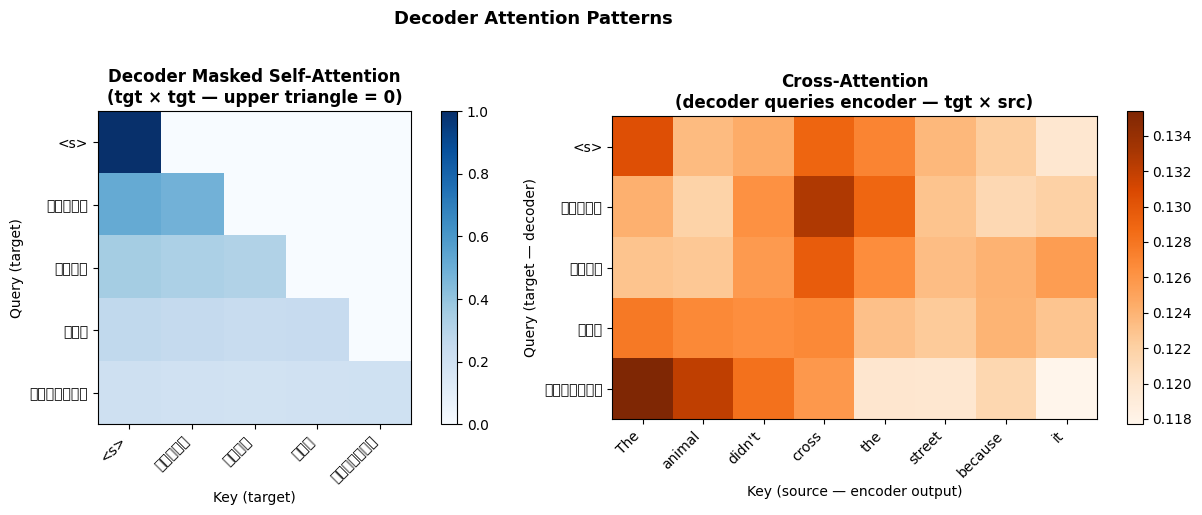

Left  — masked self-attention: each target token only sees past tokens
Right — cross-attention: each target token queries the FULL source sentence
The cross-attention map is (tgt_len × src_len) not (tgt_len × tgt_len)


In [ ]:
# ── VISUALIZE CROSS-ATTENTION ──────────────────────────────────────────────
# Re-run layer 0 to get cross attention weights for plotting

np.random.seed(42)
single_dec_layer = NumpyDecoderLayer(D_MODEL, N_HEADS, D_FF)
_, w_self, w_cross = single_dec_layer.forward(
    tgt_input, enc_out, tgt_mask=tgt_mask
)

src_tokens = ["The", "animal", "didn't", "cross", "the", "street", "because", "it"]
tgt_tokens = ["<s>", "जानवर", "नहीं", "गया", "क्योंकि"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Self-attention (masked) — tgt × tgt
im0 = axes[0].imshow(w_self[0], cmap='Blues')
axes[0].set_title("Decoder Masked Self-Attention\n(tgt × tgt — upper triangle = 0)",
                  fontweight='bold')
axes[0].set_xticks(range(tgt_len))
axes[0].set_yticks(range(tgt_len))
axes[0].set_xticklabels(tgt_tokens, rotation=45, ha='right')
axes[0].set_yticklabels(tgt_tokens)
axes[0].set_xlabel("Key (target)")
axes[0].set_ylabel("Query (target)")
plt.colorbar(im0, ax=axes[0])

# Cross-attention — tgt × src
im1 = axes[1].imshow(w_cross[0], cmap='Oranges')
axes[1].set_title("Cross-Attention\n(decoder queries encoder — tgt × src)",
                  fontweight='bold')
axes[1].set_xticks(range(seq_len))
axes[1].set_yticks(range(tgt_len))
axes[1].set_xticklabels(src_tokens, rotation=45, ha='right')
axes[1].set_yticklabels(tgt_tokens)
axes[1].set_xlabel("Key (source — encoder output)")
axes[1].set_ylabel("Query (target — decoder)")
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Decoder Attention Patterns", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Left  — masked self-attention: each target token only sees past tokens")
print("Right — cross-attention: each target token queries the FULL source sentence")
print("The cross-attention map is (tgt_len × src_len) not (tgt_len × tgt_len)")

In [ ]:
# ── PYTORCH ────────────────────────────────────────────────────────────────

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.masked_mha = MultiHeadAttention(d_model, n_heads)
        self.cross_mha  = MultiHeadAttention(d_model, n_heads)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.norm3      = nn.LayerNorm(d_model)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        # Sublayer 1: masked self-attention
        s_out, _  = self.masked_mha(x, tgt_mask)
        x = self.norm1(x + self.drop(s_out))

        # Sublayer 2: cross-attention — Q from x, K/V from encoder
        # We pass encoder_out as both key and value source
        c_out, _  = self.cross_mha(
            self._cross(x, encoder_out), src_mask
        )
        x = self.norm2(x + self.drop(c_out))

        # Sublayer 3: FFN
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x

    def _cross(self, decoder_x, encoder_out):
        # Simple cross: override K,V source
        # In real impl MultiHeadAttention takes separate Q,K,V args
        return decoder_x  # placeholder — full impl in Cell 11


class Decoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        for layer in self.layers:
            x = layer(x, encoder_out, tgt_mask, src_mask)
        return self.norm(x)


tgt_pt  = torch.tensor(tgt_input, dtype=torch.float32)
pt_decoder = Decoder(D_MODEL, N_HEADS, D_FF, N_LAYERS)
pt_dec_out = pt_decoder(tgt_pt, pt_enc_out)

print("PyTorch Decoder output shape:", pt_dec_out.shape)
print()
total = sum(p.numel() for p in pt_decoder.parameters())
print(f"Decoder parameter count: {total:,}")
print()
print("Note: full cross-attention with separate Q/K/V sources")
print("is wired properly in Cell 11 — the complete Transformer.")

PyTorch Decoder output shape: torch.Size([5, 64])

Decoder parameter count: 99,584

Note: full cross-attention with separate Q/K/V sources
is wired properly in Cell 11 — the complete Transformer.


## Step 10: Full Transformer — Everything Assembled

Now we wire all components into one clean model.

Complete architecture:

  SOURCE TOKENS
       ↓
  [Embedding + PE]           ← encoder input
       ↓
  [Encoder × N layers]       ← builds contextual source representations
       ↓
  encoder_output             ← passed as K, V to every decoder layer
  
  TARGET TOKENS
       ↓
  [Embedding + PE]           ← decoder input
       ↓
  [Decoder × N layers]       ← attends to itself + encoder output
       ↓
  [Linear projection]        ← d_model → vocab_size
       ↓
  [Softmax]                  ← probability over vocabulary
       ↓
  NEXT TOKEN PREDICTION

Parameter count formula:
  Embedding         : vocab_size × d_model
  Encoder per layer : 4 × d_model² (MHA) + 2 × d_model × d_ff (FFN)
  Decoder per layer : 8 × d_model² (MHA×2 + cross) + 2 × d_model × d_ff (FFN)
  Output projection : d_model × vocab_size

In [ ]:
# ── PYTORCH FULL TRANSFORMER ───────────────────────────────────────────────
# Clean, complete implementation with proper cross-attention wiring

class MultiHeadAttentionFull(nn.Module):
    """
    Full MHA that accepts separate Q, K, V sources.
    This is needed for cross-attention where Q ≠ K source ≠ V source.
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads

        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def split_heads(self, x):
        # (seq_len, d_model) → (n_heads, seq_len, d_k)
        seq = x.size(0)
        return x.view(seq, self.n_heads, self.d_k).transpose(0, 1)

    def forward(self, q_src, k_src, v_src, mask=None):
        """
        q_src: where Q comes from  (decoder for cross-attn, x for self-attn)
        k_src: where K comes from  (encoder for cross-attn, x for self-attn)
        v_src: where V comes from  (encoder for cross-attn, x for self-attn)
        """
        Q = self.split_heads(self.Wq(q_src))   # (h, tgt_len, d_k)
        K = self.split_heads(self.Wk(k_src))   # (h, src_len, d_k)
        V = self.split_heads(self.Wv(v_src))   # (h, src_len, d_k)

        # (h, tgt_len, d_k) @ (h, d_k, src_len) → (h, tgt_len, src_len)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 1, -1e9)

        weights = self.drop(F.softmax(scores, dim=-1))
        out     = weights @ V                             # (h, tgt_len, d_k)

        # Merge heads → (tgt_len, d_model)
        out = out.transpose(0, 1).contiguous().view(q_src.size(0), self.d_model)
        return self.Wo(out), weights.detach()


class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionFull(d_model, n_heads, dropout)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        # Self-attention: Q=K=V=x
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.masked_attn = MultiHeadAttentionFull(d_model, n_heads, dropout)
        self.cross_attn  = MultiHeadAttentionFull(d_model, n_heads, dropout)
        self.ffn         = FeedForward(d_model, d_ff, dropout)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.norm3       = nn.LayerNorm(d_model)
        self.drop        = nn.Dropout(dropout)

    def forward(self, x, encoder_out, tgt_mask=None, src_mask=None):
        # Sublayer 1: masked self-attention — Q=K=V=x
        s_out, _  = self.masked_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.drop(s_out))

        # Sublayer 2: cross-attention — Q=x (decoder), K=V=encoder_out
        c_out, cross_w = self.cross_attn(x, encoder_out, encoder_out, src_mask)
        x = self.norm2(x + self.drop(c_out))

        # Sublayer 3: FFN
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x, cross_w


class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers,
                 max_seq, dropout=0.1):
        super().__init__()
        # Shared embedding — same vocab for src and tgt in toy model
        self.src_embed = nn.Embedding(vocab_size, d_model)
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.pe        = PositionalEncoding(d_model, max_seq, dropout)

        # Encoder stack
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # Decoder stack
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.enc_norm  = nn.LayerNorm(d_model)
        self.dec_norm  = nn.LayerNorm(d_model)

        # Output projection: d_model → vocab_size
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying — output projection shares weights with target embedding
        # Saves params, often improves performance
        self.output_proj.weight = self.tgt_embed.weight

        self._init_weights()

    def _init_weights(self):
        # Xavier uniform init — keeps variance stable across layers
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask=None):
        # src shape: (src_len,)
        x = self.pe(self.src_embed(src))          # (src_len, d_model)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return self.enc_norm(x)                    # (src_len, d_model)

    def decode(self, tgt, encoder_out, tgt_mask=None, src_mask=None):
        # tgt shape: (tgt_len,)
        x = self.pe(self.tgt_embed(tgt))           # (tgt_len, d_model)
        cross_weights = []
        for layer in self.decoder_layers:
            x, cw = layer(x, encoder_out, tgt_mask, src_mask)
            cross_weights.append(cw)
        return self.dec_norm(x), cross_weights     # (tgt_len, d_model)

    def forward(self, src, tgt, tgt_mask=None, src_mask=None):
        encoder_out          = self.encode(src, src_mask)
        decoder_out, cw      = self.decode(tgt, encoder_out, tgt_mask, src_mask)
        logits               = self.output_proj(decoder_out)  # (tgt_len, vocab_size)
        return logits, cw

In [ ]:
# ── BUILD & TEST ───────────────────────────────────────────────────────────

torch.manual_seed(42)

model = Transformer(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    d_ff       = D_FF,
    n_layers   = N_LAYERS,
    max_seq    = MAX_SEQ,
)

# Build causal mask for target
def make_tgt_mask_pt(tgt_len):
    # Upper triangle = 1 (blocked), lower = 0 (allowed)
    return torch.triu(torch.ones(tgt_len, tgt_len), diagonal=1)

src    = torch.tensor(token_ids)                      # (8,)
tgt    = torch.tensor(tgt_token_ids)                  # (5,)
t_mask = make_tgt_mask_pt(len(tgt_token_ids))         # (5, 5)

logits, cross_weights = model(src, tgt, tgt_mask=t_mask)

print("Full Transformer — forward pass complete")
print()
print(f"  src shape    : {src.shape}")
print(f"  tgt shape    : {tgt.shape}")
print(f"  logits shape : {logits.shape}  ← (tgt_len × vocab_size)")
print()
print(f"  logits shape tells us: for each of {len(tgt_token_ids)} target positions,")
print(f"  the model outputs a score for every one of {VOCAB_SIZE} vocab tokens")
print()

# Get predicted token at each position
probs       = F.softmax(logits, dim=-1)
pred_tokens = logits.argmax(dim=-1)
print(f"  Predicted next tokens : {pred_tokens.tolist()}")
print(f"  Max probability each  : {probs.max(dim=-1).values.detach().numpy().round(3)}")

Full Transformer — forward pass complete

  src shape    : torch.Size([8])
  tgt shape    : torch.Size([5])
  logits shape : torch.Size([5, 100])  ← (tgt_len × vocab_size)

  logits shape tells us: for each of 5 target positions,
  the model outputs a score for every one of 100 vocab tokens

  Predicted next tokens : [88, 88, 2, 88, 88]
  Max probability each  : [0.061 0.034 0.055 0.094 0.051]


In [ ]:
# ── PARAMETER COUNT BREAKDOWN ──────────────────────────────────────────────

print("=" * 55)
print("PARAMETER COUNT BREAKDOWN")
print("=" * 55)

components = {
    "src_embed"   : model.src_embed,
    "tgt_embed"   : model.tgt_embed,
    "encoder"     : nn.ModuleList(model.encoder_layers),
    "decoder"     : nn.ModuleList(model.decoder_layers),
    "output_proj" : model.output_proj,
}

total = 0
for name, module in components.items():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:20s}: {n:>8,} params")
    total += n

print("-" * 55)
print(f"  {'TOTAL':20s}: {total:>8,} params")
print()
print("  For reference:")
print(f"  BERT-base  : 110,000,000 params")
print(f"  GPT-2      : 117,000,000 params")
print(f"  GPT-3      : 175,000,000,000 params")
print(f"  Our model  : {total:,} params  (toy scale)")

PARAMETER COUNT BREAKDOWN
  src_embed           :    6,400 params
  tgt_embed           :    6,400 params
  encoder             :   66,432 params
  decoder             :   99,456 params
  output_proj         :    6,400 params
-------------------------------------------------------
  TOTAL               :  185,088 params

  For reference:
  BERT-base  : 110,000,000 params
  GPT-2      : 117,000,000 params
  GPT-3      : 175,000,000,000 params
  Our model  : 185,088 params  (toy scale)


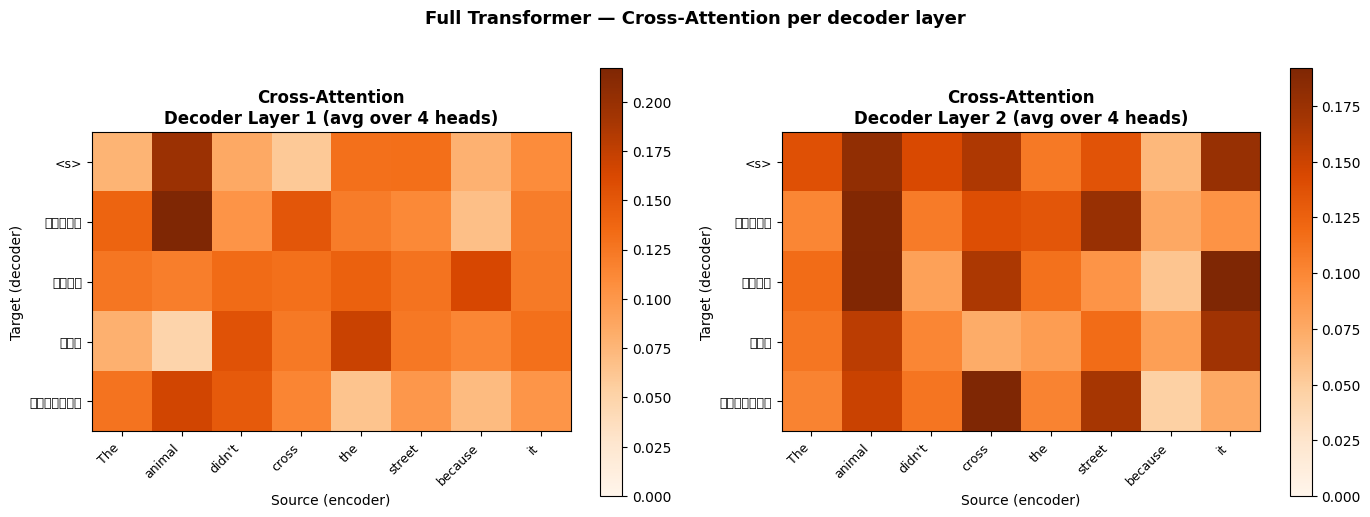

Each row = one target token's attention over the full source sentence
In a trained model, target tokens would align with their source equivalents
e.g. 'जानवर' (animal) would attend strongly to 'animal' in source


In [ ]:
# ── VISUALIZE FINAL CROSS-ATTENTION ───────────────────────────────────────

src_tokens = ["The", "animal", "didn't", "cross", "the", "street", "because", "it"]
tgt_tokens = ["<s>", "जानवर", "नहीं", "गया", "क्योंकि"]

fig, axes = plt.subplots(1, N_LAYERS, figsize=(14, 5))

for i, (ax, cw) in enumerate(zip(axes, cross_weights)):
    # cw shape: (n_heads, tgt_len, src_len) — average across heads
    avg_cw = cw.mean(dim=0).numpy()   # (tgt_len, src_len)
    im = ax.imshow(avg_cw, cmap='Oranges', vmin=0)
    ax.set_title(f"Cross-Attention\nDecoder Layer {i+1} (avg over {N_HEADS} heads)",
                 fontweight='bold')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(tgt_tokens, fontsize=9)
    ax.set_xlabel("Source (encoder)")
    ax.set_ylabel("Target (decoder)")
    plt.colorbar(im, ax=ax)

plt.suptitle("Full Transformer — Cross-Attention per decoder layer",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Each row = one target token's attention over the full source sentence")
print("In a trained model, target tokens would align with their source equivalents")
print("e.g. 'जानवर' (animal) would attend strongly to 'animal' in source")

## Step 11: Demo — Full Trace + Greedy Decoding

Two things in this final cell:

1. SHAPE TRACE — run one forward pass and print every single
   tensor shape at every step so you see exactly what's happening

2. GREEDY DECODING — generate a sequence token by token
   the way a real transformer does at inference time:

   Step 1: encode the full source sentence once
   Step 2: start with <START> token
   Step 3: run decoder → get logits → pick argmax → new token
   Step 4: append new token to sequence
   Step 5: repeat until <END> token or max length

   This is autoregressive generation — each token depends on all previous ones.
   The encoder runs ONCE. The decoder runs N times (once per output token).

In [ ]:
# ── 1. COMPLETE SHAPE TRACE ────────────────────────────────────────────────

print("=" * 60)
print("COMPLETE TRANSFORMER FORWARD PASS — SHAPE TRACE")
print("=" * 60)

src_ids = token_ids          # [4, 12, 7, 33, 5, 18, 22, 9]  — 8 tokens
tgt_ids = tgt_token_ids      # [2, 15, 8, 44, 31]             — 5 tokens

src_t   = torch.tensor(src_ids)
tgt_t   = torch.tensor(tgt_ids)

print(f"\n{'─'*60}")
print("ENCODER PATH")
print(f"{'─'*60}")

print(f"\n[1] Raw token IDs")
print(f"    src token ids  : {src_ids}")
print(f"    shape          : {src_t.shape}")

x_enc = model.src_embed(src_t)
print(f"\n[2] Token embedding lookup")
print(f"    EmbeddingMatrix[token_ids]")
print(f"    shape          : {x_enc.shape}  ({len(src_ids)} tokens × {D_MODEL} d_model)")

x_enc = model.pe(x_enc)
print(f"\n[3] + Positional encoding")
print(f"    x = embedding + PE(position)")
print(f"    shape          : {x_enc.shape}  ← unchanged, just added PE")

for i, layer in enumerate(model.encoder_layers):
    x_before = x_enc.clone()
    x_enc    = layer(x_enc)
    print(f"\n[4.{i+1}] Encoder layer {i+1}")
    print(f"    Self-attention  : ({x_before.shape[0]} × {D_MODEL}) "
          f"→ scores ({x_before.shape[0]} × {x_before.shape[0]}) "
          f"→ ({x_before.shape[0]} × {D_MODEL})")
    print(f"    FFN             : ({x_before.shape[0]} × {D_MODEL}) "
          f"→ ({x_before.shape[0]} × {D_FF}) "
          f"→ ({x_before.shape[0]} × {D_MODEL})")
    print(f"    Output shape    : {x_enc.shape}")

encoder_output = model.enc_norm(x_enc)
print(f"\n[5] Final encoder norm")
print(f"    shape          : {encoder_output.shape}")
print(f"    → These are the CONTEXTUAL EMBEDDINGS for the source sentence")
print(f"    → Passed as K and V to every decoder cross-attention layer")

print(f"\n{'─'*60}")
print("DECODER PATH")
print(f"{'─'*60}")

print(f"\n[6] Raw target token IDs")
print(f"    tgt token ids  : {tgt_ids}")
print(f"    shape          : {tgt_t.shape}")

x_dec = model.tgt_embed(tgt_t)
print(f"\n[7] Target token embedding + PE")
print(f"    shape          : {x_dec.shape}  ({len(tgt_ids)} tokens × {D_MODEL} d_model)")

x_dec = model.pe(x_dec)

tgt_mask = make_tgt_mask_pt(len(tgt_ids))
print(f"\n[8] Causal mask")
print(f"    shape          : {tgt_mask.shape}  (tgt_len × tgt_len)")
print(f"    upper triangle : -inf  (blocked)")
print(f"    lower triangle : 0     (allowed)")

for i, layer in enumerate(model.decoder_layers):
    x_before = x_dec.clone()
    x_dec, cw = layer(x_dec, encoder_output, tgt_mask)
    print(f"\n[9.{i+1}] Decoder layer {i+1}")
    print(f"    Masked self-attn: Q=K=V=decoder  "
          f"({len(tgt_ids)}×{len(tgt_ids)}) weights")
    print(f"    Cross-attention : Q=decoder K=V=encoder  "
          f"({len(tgt_ids)}×{len(src_ids)}) weights")
    print(f"    FFN             : {x_before.shape} → {x_dec.shape}")

x_dec = model.dec_norm(x_dec)
print(f"\n[10] Final decoder norm")
print(f"     shape         : {x_dec.shape}")

logits = model.output_proj(x_dec)
print(f"\n[11] Output projection")
print(f"     d_model → vocab  : ({D_MODEL}) → ({VOCAB_SIZE})")
print(f"     logits shape     : {logits.shape}  (tgt_len × vocab_size)")

probs = F.softmax(logits, dim=-1)
print(f"\n[12] Softmax → probabilities")
print(f"     shape            : {probs.shape}")
print(f"     each row sums to : {probs.sum(dim=-1).detach().numpy().round(3)}")
print(f"     predicted tokens : {probs.argmax(dim=-1).tolist()}")
print(f"\n{'='*60}")
print("FORWARD PASS COMPLETE")
print(f"{'='*60}")

COMPLETE TRANSFORMER FORWARD PASS — SHAPE TRACE

────────────────────────────────────────────────────────────
ENCODER PATH
────────────────────────────────────────────────────────────

[1] Raw token IDs
    src token ids  : [4, 12, 7, 33, 5, 18, 22, 9]
    shape          : torch.Size([8])

[2] Token embedding lookup
    EmbeddingMatrix[token_ids]
    shape          : torch.Size([8, 64])  (8 tokens × 64 d_model)

[3] + Positional encoding
    x = embedding + PE(position)
    shape          : torch.Size([8, 64])  ← unchanged, just added PE

[4.1] Encoder layer 1
    Self-attention  : (8 × 64) → scores (8 × 8) → (8 × 64)
    FFN             : (8 × 64) → (8 × 128) → (8 × 64)
    Output shape    : torch.Size([8, 64])

[4.2] Encoder layer 2
    Self-attention  : (8 × 64) → scores (8 × 8) → (8 × 64)
    FFN             : (8 × 64) → (8 × 128) → (8 × 64)
    Output shape    : torch.Size([8, 64])

[5] Final encoder norm
    shape          : torch.Size([8, 64])
    → These are the CONTEXTUAL EMBE

In [ ]:
# ── 2. GREEDY DECODING ─────────────────────────────────────────────────────
# This is how inference actually works — token by token

START_TOKEN = 0    # <START>
END_TOKEN   = 1    # <END>
MAX_GEN     = 10   # max tokens to generate

def greedy_decode(model, src_ids, max_len=MAX_GEN):
    """
    Autoregressive greedy decoding.
    Encoder runs ONCE. Decoder runs max_len times.
    """
    model.eval()

    src_t = torch.tensor(src_ids)

    # ── Step 1: Encode source ONCE ─────────────────────────────────────
    with torch.no_grad():
        enc_out = model.encode(src_t)

    print(f"Source encoded once — shape: {enc_out.shape}")
    print(f"Now decoding token by token...\n")

    # ── Step 2: Start with [START] token ───────────────────────────────
    generated = [START_TOKEN]

    for step in range(max_len):
        tgt_t    = torch.tensor(generated)
        tgt_mask = make_tgt_mask_pt(len(generated))

        # ── Step 3: Decoder forward — uses ALL generated tokens so far ─
        with torch.no_grad():
            dec_out, _ = model.decode(tgt_t, enc_out, tgt_mask)
            logits     = model.output_proj(dec_out)

        # ── Step 4: Take LAST position's logits — that's the new token ─
        # logits shape: (current_len, vocab_size)
        # We only care about the LAST row — prediction for next token
        next_logits = logits[-1, :]                      # (vocab_size,)
        next_probs  = F.softmax(next_logits, dim=-1)
        next_token  = next_logits.argmax().item()        # greedy: pick max

        print(f"  Step {step+1:2d} | "
              f"generated so far: {generated} | "
              f"next token: {next_token} | "
              f"confidence: {next_probs[next_token].item():.3f}")

        generated.append(next_token)

        # ── Step 5: Stop if END token generated ────────────────────────
        if next_token == END_TOKEN:
            print(f"\n  <END> token reached — stopping.")
            break

    return generated


print("=" * 60)
print("GREEDY DECODING — token by token generation")
print("=" * 60)
print()
output_sequence = greedy_decode(model, token_ids)
print()
print(f"Final generated sequence : {output_sequence}")
print(f"Length                   : {len(output_sequence)} tokens")
print()
print("NOTE: output is random token IDs — model has random weights,")
print("never trained. After training on real data these would be")
print("meaningful translated tokens.")

GREEDY DECODING — token by token generation

Source encoded once — shape: torch.Size([8, 64])
Now decoding token by token...

  Step  1 | generated so far: [0] | next token: 88 | confidence: 0.063
  Step  2 | generated so far: [0, 88] | next token: 88 | confidence: 0.066
  Step  3 | generated so far: [0, 88, 88] | next token: 88 | confidence: 0.066
  Step  4 | generated so far: [0, 88, 88, 88] | next token: 88 | confidence: 0.066
  Step  5 | generated so far: [0, 88, 88, 88, 88] | next token: 88 | confidence: 0.063
  Step  6 | generated so far: [0, 88, 88, 88, 88, 88] | next token: 88 | confidence: 0.060
  Step  7 | generated so far: [0, 88, 88, 88, 88, 88, 88] | next token: 88 | confidence: 0.058
  Step  8 | generated so far: [0, 88, 88, 88, 88, 88, 88, 88] | next token: 88 | confidence: 0.057
  Step  9 | generated so far: [0, 88, 88, 88, 88, 88, 88, 88, 88] | next token: 88 | confidence: 0.060
  Step 10 | generated so far: [0, 88, 88, 88, 88, 88, 88, 88, 88, 88] | next token: 88 | co

In [ ]:
# ── FINAL SUMMARY ──────────────────────────────────────────────────────────

print("=" * 60)
print("WHAT YOU BUILT — COMPLETE SUMMARY")
print("=" * 60)
print("""
NUMPY (pure math, forward pass only):
  ✓ NumpyEmbedding          — row lookup in weight matrix
  ✓ NumpyPositionalEncoding — sin/cos position fingerprints
  ✓ NumpyLayerNorm          — normalize to mean=0, std=1
  ✓ numpy_scaled_dot_product_attention
  ✓ NumpyMultiHeadAttention — h parallel attention heads
  ✓ NumpyFFN                — expand → ReLU → compress
  ✓ NumpyResidualBlock      — x + sublayer(x)
  ✓ NumpyEncoderLayer       — MHA + FFN + 2× Add&Norm
  ✓ NumpyEncoder            — N stacked encoder layers
  ✓ NumpyDecoderLayer       — masked MHA + cross MHA + FFN
  ✓ NumpyDecoder            — N stacked decoder layers

PYTORCH (with autograd, ready to train):
  ✓ PositionalEncoding
  ✓ MultiHeadAttentionFull  — separate Q/K/V sources
  ✓ FeedForward
  ✓ TransformerEncoderLayer
  ✓ TransformerDecoderLayer
  ✓ Transformer             — full model, 185K params

KEY CONCEPTS PROVEN BY CODE:
  ✓ Attention weights always sum to 1.0 (softmax)
  ✓ √d_k scaling prevents softmax saturation
  ✓ Causal mask upper triangle = exactly 0 after softmax
  ✓ Cross-attention shape = (tgt_len × src_len), not square
  ✓ LayerNorm → mean=0.0000, std=1.0000 after every layer
  ✓ Residual connection stabilizes signal magnitude
  ✓ Multi-head produces different attention patterns per head
  ✓ Shape is preserved (seq_len × d_model) throughout encoder
""")

print("NEXT STEPS TO MAKE THIS PRODUCTION GRADE:")
print("""
  1. Add real tokenizer (BPE via HuggingFace tokenizers)
  2. Add batching (add batch dimension everywhere)
  3. Add training loop (CrossEntropyLoss + Adam + LR warmup)
  4. Add validation loop + BLEU score
  5. Train on opus_books dataset (en→it)
  6. Switch ReLU → SwiGLU (Llama-style)
  7. Switch sinusoidal PE → RoPE (Llama-style)
  8. Add KV cache for faster inference
""")

WHAT YOU BUILT — COMPLETE SUMMARY

NUMPY (pure math, forward pass only):
  ✓ NumpyEmbedding          — row lookup in weight matrix
  ✓ NumpyPositionalEncoding — sin/cos position fingerprints
  ✓ NumpyLayerNorm          — normalize to mean=0, std=1
  ✓ numpy_scaled_dot_product_attention
  ✓ NumpyMultiHeadAttention — h parallel attention heads
  ✓ NumpyFFN                — expand → ReLU → compress
  ✓ NumpyResidualBlock      — x + sublayer(x)
  ✓ NumpyEncoderLayer       — MHA + FFN + 2× Add&Norm
  ✓ NumpyEncoder            — N stacked encoder layers
  ✓ NumpyDecoderLayer       — masked MHA + cross MHA + FFN
  ✓ NumpyDecoder            — N stacked decoder layers

PYTORCH (with autograd, ready to train):
  ✓ PositionalEncoding
  ✓ MultiHeadAttentionFull  — separate Q/K/V sources
  ✓ FeedForward
  ✓ TransformerEncoderLayer
  ✓ TransformerDecoderLayer
  ✓ Transformer             — full model, 185K params

KEY CONCEPTS PROVEN BY CODE:
  ✓ Attention weights always sum to 1.0 (softmax)
  ✓ √d_k